# 전체 Augmentation MixUp/CutMix `alpha=0.2, p=0.5` 실험

기존 `node-2-final.ipynb`, `node-2-alpha02.ipynb`와 결과 폴더는 수정하지 않습니다.
이 노트북은 네 가지 image augmentation과 MixUp/CutMix 조합 8개를 별도 폴더에 저장합니다.

각 실험에서 매 batch마다 독립적으로 50% 확률로 MixUp 또는 CutMix를 적용하고,
나머지 batch는 원본 이미지와 원본 label로 학습합니다.

> 실행 전 **커널을 재시작하고 위에서부터 순서대로 실행**하세요.


## 1. 환경 초기화와 공통 설정

Python garbage collection과 CUDA cache 정리는 메모리만 반환합니다.
기존 모델의 파라미터나 학습 상태를 새 모델로 전달하지 않습니다.


In [16]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SEED = 42
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 0.001
MIX_ALPHA = 0.2
MIX_PROBABILITY = 0.5
NUM_WORKERS = 2
COOLDOWN_EVERY_EPOCHS = 5
COOLDOWN_SECONDS = 60

DATASET_DIR = Path("~/datasets/stanfordimagenetdogs/Images").expanduser()
RESULT_DIR = Path("results_resnet50_aug_alpha02_p05")
HISTORY_DIR = RESULT_DIR / "histories"
ORIGINAL_RESULT_DIR = Path("results_resnet50_aug")
ALPHA02_RESULT_DIR = Path("results_resnet50_aug_alpha02")

RESULT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Device: {DEVICE}")
print(f"Alpha 0.2, p=0.5 results: {RESULT_DIR.resolve()}")
print(f"Original results (read only): {ORIGINAL_RESULT_DIR.resolve()}")


Device: cuda
Alpha 0.2, p=0.5 results: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_aug_alpha02_p05
Original results (read only): /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_aug


## 2. 동일한 데이터 분할과 augmentation transform

기존 실험과 같은 seed, 분할 비율, 입력 크기, 정규화를 사용합니다.
validation 데이터에는 augmentation을 적용하지 않습니다.


In [17]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"데이터셋을 찾을 수 없습니다: {DATASET_DIR}"
    )


def base_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5],
        ),
    ])


def augment_basic():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1),
    ])


def augment_morejitter():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
        ),
    ])


def augment_rotationaug():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
        ),
    ])


AUGMENTATIONS = {
    "none": None,
    "basic": augment_basic,
    "morejitter": augment_morejitter,
    "rotationaug": augment_rotationaug,
}


full_dataset = ImageFolder(root=DATASET_DIR, transform=base_transform())
total_size = len(full_dataset)
train_size = int(0.583 * total_size)
val_size = total_size - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=split_generator,
)

class_names = full_dataset.classes
num_classes = len(class_names)


def indices_fingerprint(indices):
    index_array = np.asarray(list(indices), dtype=np.int64)
    return hashlib.sha256(index_array.tobytes()).hexdigest()


train_indices_sha256 = indices_fingerprint(train_subset.indices)
val_indices_sha256 = indices_fingerprint(val_subset.indices)

print(f"Classes: {num_classes}")
print(f"Train: {len(train_subset):,} | Validation: {len(val_subset):,}")
print(f"Train indices SHA256: {train_indices_sha256}")
print(f"Validation indices SHA256: {val_indices_sha256}")


Classes: 120
Train: 11,998 | Validation: 8,582
Train indices SHA256: 77811abc456327ae4a99911df61fc926fd75541cedff92bdda2aef045a247492
Validation indices SHA256: c718b1070073d063d393f0d926409ad57a9e70b8534c5212d9a04bf3ca2c1ad1


In [18]:
def compose_train_transform(augmentation_name):
    augmentation_factory = AUGMENTATIONS[augmentation_name]
    if augmentation_factory is None:
        return base_transform()

    return transforms.Compose([
        *augmentation_factory().transforms,
        *base_transform().transforms,
    ])


def make_loader(
    subset,
    augmentation_name="none",
    is_validation=False,
    seed=SEED,
):
    dataset_copy = copy.copy(subset.dataset)
    dataset_copy.transform = (
        base_transform()
        if is_validation
        else compose_train_transform(augmentation_name)
    )
    isolated_subset = Subset(dataset_copy, subset.indices)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        isolated_subset,
        batch_size=BATCH_SIZE,
        shuffle=not is_validation,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


val_loader = make_loader(
    val_subset,
    augmentation_name="none",
    is_validation=True,
)
sample_loader = make_loader(
    train_subset,
    augmentation_name="rotationaug",
)
sample_images, sample_labels = next(iter(sample_loader))

assert sample_images.shape[1:] == (3, 224, 224)
print(f"Batch shape: {sample_images.shape}")
del sample_images, sample_labels, sample_loader


Batch shape: torch.Size([16, 3, 224, 224])


## 3. 동일한 초기 모델과 fingerprint

pretrained 가중치와 새 FC layer를 한 번만 초기화한 뒤,
모든 실험 모델이 같은 `state_dict`에서 시작하는지 검사합니다.


In [19]:
set_seed()
base_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)
initial_model_state = copy.deepcopy(base_model.state_dict())
del base_model


def state_dict_fingerprint(state_dict):
    digest = hashlib.sha256()
    for name in sorted(state_dict):
        tensor = state_dict[name].detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(tensor.dtype).encode("utf-8"))
        digest.update(np.asarray(tensor.shape, dtype=np.int64).tobytes())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


initial_model_sha256 = state_dict_fingerprint(initial_model_state)


def create_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(initial_model_state)
    return model


verification_model_a = create_model()
verification_model_b = create_model()
assert all(
    torch.equal(
        verification_model_a.state_dict()[name],
        verification_model_b.state_dict()[name],
    )
    for name in initial_model_state
)
assert state_dict_fingerprint(
    verification_model_a.state_dict()
) == initial_model_sha256
assert state_dict_fingerprint(
    verification_model_b.state_dict()
) == initial_model_sha256

del verification_model_a, verification_model_b
gc.collect()

print(f"Initial model SHA256: {initial_model_sha256}")
print("모든 신규 모델에 사용할 초기 state_dict 동일성 검사를 통과했습니다.")


Initial model SHA256: 0d7d077cf589e581e6b94d03e07a85d3911a46f683b9972684498327d005c960
모든 신규 모델에 사용할 초기 state_dict 동일성 검사를 통과했습니다.


## 4. Alpha를 명시적으로 전달하는 MixUp/CutMix

`alpha=0.2`인 Beta 분포는 0과 1 근처의 값이 자주 나옵니다.
따라서 `alpha=1.0`보다 두 이미지가 비슷한 비율로 강하게 섞이는 경우가 줄어듭니다.


In [20]:
def mixup_batch(images, labels, alpha):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1.0 - lam) * images[indices]
    return mixed_images, labels, labels[indices], lam


def cutmix_batch(images, labels, alpha):
    lam = float(np.random.beta(alpha, alpha))
    indices = torch.randperm(images.size(0), device=images.device)

    height, width = images.shape[-2:]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    center_x = torch.randint(width, (1,), device=images.device).item()
    center_y = torch.randint(height, (1,), device=images.device).item()

    x1 = max(center_x - cut_width // 2, 0)
    x2 = min(center_x + cut_width // 2, width)
    y1 = max(center_y - cut_height // 2, 0)
    y2 = min(center_y + cut_height // 2, height)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[
        indices, :, y1:y2, x1:x2
    ]

    replaced_ratio = ((x2 - x1) * (y2 - y1)) / (width * height)
    adjusted_lam = float(1.0 - replaced_ratio)
    assert 0.0 <= adjusted_lam <= 1.0

    return mixed_images, labels, labels[indices], adjusted_lam


test_images = torch.randn(4, 3, 224, 224, device=DEVICE)
test_labels = torch.arange(4, device=DEVICE)
_, _, _, mixup_lam = mixup_batch(test_images, test_labels, MIX_ALPHA)
_, _, _, cutmix_lam = cutmix_batch(test_images, test_labels, MIX_ALPHA)
assert 0.0 <= mixup_lam <= 1.0
assert 0.0 <= cutmix_lam <= 1.0
del test_images, test_labels


## 5. 공통 학습·검증 함수


In [6]:
def evaluate(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
            total += batch_size

    return running_loss / total, 100.0 * correct / total


def train_experiment(model, train_loader, val_loader, experiment):
    set_seed(experiment["seed"])
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

    history = {
        "experiment": experiment["name"],
        "seed": experiment["seed"],
        "epochs": experiment["epochs"],
        "mix_alpha": experiment["mix_alpha"],
        "mix_probability": experiment["mix_probability"],
        "augmentation": experiment["augmentation"],
        "batch_mix": experiment["batch_mix"],
        "initial_model_sha256": initial_model_sha256,
        "train_indices_sha256": train_indices_sha256,
        "val_indices_sha256": val_indices_sha256,
        "train_loss": [],
        "train_accuracy": [],
        "mixed_batches": [],
        "total_batches": [],
        "actual_mix_ratio": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(1, experiment["epochs"] + 1):
        model.train()
        running_loss = 0.0
        weighted_correct = 0.0
        total = 0
        mixed_batches = 0
        total_batches = 0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            apply_batch_mix = random.random() < experiment["mix_probability"]
            total_batches += 1

            if apply_batch_mix:
                mixed_batches += 1
                if experiment["batch_mix"] == "mixup":
                    model_images, labels_a, labels_b, lam = mixup_batch(
                        images, labels, experiment["mix_alpha"]
                    )
                elif experiment["batch_mix"] == "cutmix":
                    model_images, labels_a, labels_b, lam = cutmix_batch(
                        images, labels, experiment["mix_alpha"]
                    )
                else:
                    raise ValueError("batch_mix must be mixup or cutmix")
            else:
                model_images = images
                labels_a = labels_b = labels
                lam = 1.0

            optimizer.zero_grad()
            outputs = model(model_images)
            loss = (
                lam * criterion(outputs, labels_a)
                + (1.0 - lam) * criterion(outputs, labels_b)
            )
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            weighted_correct += (
                lam * predicted.eq(labels_a).sum().item()
                + (1.0 - lam) * predicted.eq(labels_b).sum().item()
            )
            total += batch_size

        train_loss = running_loss / total
        train_accuracy = 100.0 * weighted_correct / total
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        actual_mix_ratio = mixed_batches / total_batches

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["mixed_batches"].append(mixed_batches)
        history["total_batches"].append(total_batches)
        history["actual_mix_ratio"].append(actual_mix_ratio)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"[{experiment['name']}] Epoch "
            f"{epoch:02d}/{experiment['epochs']} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.2f}% | "
            f"mixed {mixed_batches}/{total_batches} "
            f"({actual_mix_ratio:.3f}) | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.2f}%"
        )

        if (
            epoch % COOLDOWN_EVERY_EPOCHS == 0
            and epoch < experiment["epochs"]
        ):
            print(
                f"GPU 냉각을 위해 {COOLDOWN_SECONDS}초간 대기합니다. "
                f"({epoch}/{experiment['epochs']} epoch 완료)"
            )
            time.sleep(COOLDOWN_SECONDS)

    return history


## 6. 신규 실험 설정과 독립 저장

저장된 history를 건너뛰려면 epoch 수뿐 아니라 alpha, seed, augmentation,
batch mixing 방식과 fingerprint가 모두 일치해야 합니다.


In [7]:
EXPERIMENTS_ALPHA02 = [
    {
        "name": "rotationaug_mixup_alpha0.2_p0.5",
        "augmentation": "rotationaug",
        "batch_mix": "mixup",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "rotationaug_cutmix_alpha0.2_p0.5",
        "augmentation": "rotationaug",
        "batch_mix": "cutmix",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "no_aug_mixup_alpha0.2_p0.5",
        "augmentation": "none",
        "batch_mix": "mixup",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "no_aug_cutmix_alpha0.2_p0.5",
        "augmentation": "none",
        "batch_mix": "cutmix",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "basic_mixup_alpha0.2_p0.5",
        "augmentation": "basic",
        "batch_mix": "mixup",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "basic_cutmix_alpha0.2_p0.5",
        "augmentation": "basic",
        "batch_mix": "cutmix",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "morejitter_mixup_alpha0.2_p0.5",
        "augmentation": "morejitter",
        "batch_mix": "mixup",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    {
        "name": "morejitter_cutmix_alpha0.2_p0.5",
        "augmentation": "morejitter",
        "batch_mix": "cutmix",
        "mix_alpha": MIX_ALPHA,
        "mix_probability": MIX_PROBABILITY,
        "seed": SEED,
        "epochs": EPOCHS,
    },
]

experiment_config = {
    "model": "resnet50",
    "weights": "IMAGENET1K_V1",
    "dataset": str(DATASET_DIR),
    "num_classes": num_classes,
    "train_size": len(train_subset),
    "validation_size": len(val_subset),
    "image_size": [224, 224],
    "normalization_mean": [0.5, 0.5, 0.5],
    "normalization_std": [0.5, 0.5, 0.5],
    "epochs": EPOCHS,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "optimizer": "SGD",
    "learning_rate": LEARNING_RATE,
    "mix_alpha": MIX_ALPHA,
    "mix_probability": MIX_PROBABILITY,
    "initial_model_sha256": initial_model_sha256,
    "train_indices_sha256": train_indices_sha256,
    "val_indices_sha256": val_indices_sha256,
    "experiments": EXPERIMENTS_ALPHA02,
}

with (RESULT_DIR / "experiment_config.json").open("w", encoding="utf-8") as file:
    json.dump(experiment_config, file, ensure_ascii=False, indent=2)


def history_matches_experiment(history, experiment):
    return (
        len(history.get("val_accuracy", [])) == experiment["epochs"]
        and history.get("epochs") == experiment["epochs"]
        and history.get("seed") == experiment["seed"]
        and history.get("mix_alpha") == experiment["mix_alpha"]
        and history.get("mix_probability") == experiment["mix_probability"]
        and history.get("augmentation") == experiment["augmentation"]
        and history.get("batch_mix") == experiment["batch_mix"]
        and history.get("initial_model_sha256") == initial_model_sha256
        and history.get("train_indices_sha256") == train_indices_sha256
        and history.get("val_indices_sha256") == val_indices_sha256
    )


def histories_to_dataframe(histories):
    rows = []
    for experiment_name, history in histories.items():
        for epoch_index in range(len(history["val_accuracy"])):
            rows.append({
                "experiment": experiment_name,
                "epoch": epoch_index + 1,
                "seed": history["seed"],
                "mix_alpha": history["mix_alpha"],
                "mix_probability": history["mix_probability"],
                "augmentation": history["augmentation"],
                "batch_mix": history["batch_mix"],
                "train_loss": history["train_loss"][epoch_index],
                "train_accuracy": history["train_accuracy"][epoch_index],
                "mixed_batches": history["mixed_batches"][epoch_index],
                "total_batches": history["total_batches"][epoch_index],
                "actual_mix_ratio": history["actual_mix_ratio"][epoch_index],
                "val_loss": history["val_loss"][epoch_index],
                "val_accuracy": history["val_accuracy"][epoch_index],
            })
    return pd.DataFrame(rows)


def build_summary(histories):
    rows = []
    for experiment_name, history in histories.items():
        best_index = int(np.argmax(history["val_accuracy"]))
        rows.append({
            "experiment": experiment_name,
            "augmentation": history["augmentation"],
            "batch_mix": history["batch_mix"],
            "mix_alpha": history["mix_alpha"],
            "mix_probability": history["mix_probability"],
            "mean_actual_mix_ratio": np.mean(history["actual_mix_ratio"]),
            "best_epoch": best_index + 1,
            "best_val_accuracy": history["val_accuracy"][best_index],
            "final_val_accuracy": history["val_accuracy"][-1],
            "final_val_loss": history["val_loss"][-1],
        })
    return pd.DataFrame(rows)


def save_results(histories):
    history_df = histories_to_dataframe(histories)
    summary_df = build_summary(histories)
    history_df.to_csv(RESULT_DIR / "training_history.csv", index=False)
    summary_df.to_csv(RESULT_DIR / "experiment_summary.csv", index=False)
    return history_df, summary_df


## 7. Alpha 0.2, p=0.5 전체 8개 실험 실행

각 실험은 새로운 모델과 optimizer로 시작합니다.
완료된 실험은 metadata와 fingerprint가 모두 일치할 때만 건너뜁니다.


In [8]:
alpha02_histories = {}

for experiment in EXPERIMENTS_ALPHA02:
    experiment_name = experiment["name"]
    history_path = HISTORY_DIR / f"{experiment_name}.pt"

    if history_path.exists():
        saved_history = torch.load(history_path, map_location="cpu")
        if history_matches_experiment(saved_history, experiment):
            alpha02_histories[experiment_name] = saved_history
            print(f"[SKIP] {experiment_name}: 검증된 결과를 불러왔습니다.")
            save_results(alpha02_histories)
            continue

        print(
            f"[RESTART] {experiment_name}: 저장 결과의 설정 또는 "
            "fingerprint가 현재 실험과 다릅니다."
        )

    print(f"\n{'=' * 75}")
    print(
        f"Start: {experiment_name} | "
        f"batch_mix={experiment['batch_mix']} | "
        f"alpha={experiment['mix_alpha']} | "
        f"p={experiment['mix_probability']}"
    )
    print(f"{'=' * 75}")

    train_loader = make_loader(
        train_subset,
        augmentation_name=experiment["augmentation"],
        is_validation=False,
        seed=experiment["seed"],
    )
    model = create_model()
    assert state_dict_fingerprint(model.state_dict()) == initial_model_sha256

    history = train_experiment(
        model,
        train_loader,
        val_loader,
        experiment,
    )

    assert history_matches_experiment(history, experiment)
    torch.save(history, history_path)
    alpha02_histories[experiment_name] = history
    save_results(alpha02_histories)

    model.to("cpu")
    del model, train_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

alpha02_history_df, alpha02_summary_df = save_results(alpha02_histories)
print("\nAlpha 0.2, p=0.5 전체 8개 실험이 완료되어 저장되었습니다.")



Start: rotationaug_mixup_alpha0.2_p0.5 | batch_mix=mixup | alpha=0.2 | p=0.5


/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


[rotationaug_mixup_alpha0.2_p0.5] Epoch 01/20 | train loss 4.4913 | train acc 12.99% | mixed 372/750 (0.496) | val loss 3.9318 | val acc 38.67%
[rotationaug_mixup_alpha0.2_p0.5] Epoch 02/20 | train loss 3.6916 | train acc 42.11% | mixed 362/750 (0.483) | val loss 2.8512 | val acc 60.48%
[rotationaug_mixup_alpha0.2_p0.5] Epoch 03/20 | train loss 2.9278 | train acc 55.57% | mixed 362/750 (0.483) | val loss 2.0220 | val acc 68.97%
[rotationaug_mixup_alpha0.2_p0.5] Epoch 04/20 | train loss 2.3715 | train acc 62.79% | mixed 375/750 (0.500) | val loss 1.4949 | val acc 74.57%
[rotationaug_mixup_alpha0.2_p0.5] Epoch 05/20 | train loss 2.0155 | train acc 66.36% | mixed 363/750 (0.484) | val loss 1.2074 | val acc 76.77%
GPU 냉각을 위해 60초간 대기합니다. (5/20 epoch 완료)
[rotationaug_mixup_alpha0.2_p0.5] Epoch 06/20 | train loss 1.7817 | train acc 68.49% | mixed 390/750 (0.520) | val loss 1.0012 | val acc 78.92%
[rotationaug_mixup_alpha0.2_p0.5] Epoch 07/20 | train loss 1.5613 | train acc 71.89% | mixed 370/

## 8. 저장된 Alpha 0.2, p=0.5 결과 재로딩

학습을 다시 하지 않고 이 셀부터 실행해 신규 실험 결과와 표를 확인할 수 있습니다.


In [9]:
alpha02_history_df = pd.read_csv(RESULT_DIR / "training_history.csv")
alpha02_summary_df = pd.read_csv(RESULT_DIR / "experiment_summary.csv")

expected_experiments = {
    experiment["name"] for experiment in EXPERIMENTS_ALPHA02
}
saved_experiments = set(alpha02_history_df["experiment"].unique())
missing_experiments = expected_experiments - saved_experiments

if missing_experiments:
    print(f"아직 완료되지 않은 실험: {sorted(missing_experiments)}")
else:
    epoch_counts = alpha02_history_df.groupby("experiment")["epoch"].count()
    assert (epoch_counts == EPOCHS).all()
    assert (alpha02_history_df["mix_alpha"] == MIX_ALPHA).all()
    assert (alpha02_history_df["mix_probability"] == MIX_PROBABILITY).all()
    assert not alpha02_history_df.duplicated(["experiment", "epoch"]).any()
    assert not alpha02_history_df.isna().any().any()
    mean_ratio = alpha02_history_df["actual_mix_ratio"].mean()
    assert 0.45 <= mean_ratio <= 0.55
    print(
        "Alpha 0.2, p=0.5 전체 8개 실험의 20 epoch 결과가 "
        f"확인되었습니다. 전체 평균 적용 비율: {mean_ratio:.3f}"
    )

display(alpha02_summary_df.round(4))


Alpha 0.2, p=0.5 전체 8개 실험의 20 epoch 결과가 확인되었습니다. 전체 평균 적용 비율: 0.499


,experiment,augmentation,batch_mix,mix_alpha,mix_probability,mean_actual_mix_ratio,best_epoch,best_val_accuracy,final_val_accuracy,final_val_loss
0,rotationaug_mixup_alpha0.2_p0.5,rotationaug,mixup,0.2,0.5,0.4993,18,84.6772,84.6539,0.5444
1,rotationaug_cutmix_alpha0.2_p0.5,rotationaug,cutmix,0.2,0.5,0.4993,17,84.6190,84.5607,0.5599
2,no_aug_mixup_alpha0.2_p0.5,none,mixup,0.2,0.5,0.4993,20,84.3044,84.3044,0.5563
3,no_aug_cutmix_alpha0.2_p0.5,none,cutmix,0.2,0.5,0.4993,18,84.4908,84.4209,0.5679
4,basic_mixup_alpha0.2_p0.5,basic,mixup,0.2,0.5,0.4993,20,84.6073,84.6073,0.5458
5,basic_cutmix_alpha0.2_p0.5,basic,cutmix,0.2,0.5,0.4993,18,84.8054,84.6889,0.5578
6,morejitter_mixup_alpha0.2_p0.5,morejitter,mixup,0.2,0.5,0.4993,20,84.5491,84.5491,0.5467
7,morejitter_cutmix_alpha0.2_p0.5,morejitter,cutmix,0.2,0.5,0.4993,20,84.7122,84.7122,0.5598


## 9. 기존 결과와 7개 조건 비교

기존 alpha=1.0 및 alpha=0.2 결과는 읽기만 하며 원본 파일을 수정하지 않습니다.


In [10]:
required_files = [
    ORIGINAL_RESULT_DIR / "training_history.csv",
    ALPHA02_RESULT_DIR / "training_history.csv",
    RESULT_DIR / "training_history.csv",
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"비교에 필요한 파일이 없습니다: {missing_files}")

original_df = pd.read_csv(ORIGINAL_RESULT_DIR / "training_history.csv")
alpha02_df = pd.read_csv(ALPHA02_RESULT_DIR / "training_history.csv")
p05_df = pd.read_csv(RESULT_DIR / "training_history.csv")

original_metadata = {
    experiment["name"]: experiment for experiment in [
        {"name": "no_aug", "augmentation": "none", "batch_mix": "none"},
        {"name": "basic", "augmentation": "basic", "batch_mix": "none"},
        {"name": "morejitter", "augmentation": "morejitter", "batch_mix": "none"},
        {"name": "rotationaug", "augmentation": "rotationaug", "batch_mix": "none"},
        {"name": "no_aug_mixup", "augmentation": "none", "batch_mix": "mixup"},
        {"name": "no_aug_cutmix", "augmentation": "none", "batch_mix": "cutmix"},
        {"name": "basic_mixup", "augmentation": "basic", "batch_mix": "mixup"},
        {"name": "basic_cutmix", "augmentation": "basic", "batch_mix": "cutmix"},
        {"name": "morejitter_mixup", "augmentation": "morejitter", "batch_mix": "mixup"},
        {"name": "morejitter_cutmix", "augmentation": "morejitter", "batch_mix": "cutmix"},
        {"name": "rotationaug_mixup", "augmentation": "rotationaug", "batch_mix": "mixup"},
        {"name": "rotationaug_cutmix", "augmentation": "rotationaug", "batch_mix": "cutmix"},
    ]
}
original_df["augmentation"] = original_df["experiment"].map(
    lambda name: original_metadata[name]["augmentation"]
)
original_df["batch_mix"] = original_df["experiment"].map(
    lambda name: original_metadata[name]["batch_mix"]
)
original_df["mix_alpha"] = original_df["batch_mix"].map(
    lambda method: np.nan if method == "none" else 1.0
)
original_df["mix_probability"] = original_df["batch_mix"].map(
    lambda method: np.nan if method == "none" else 1.0
)
alpha02_df["mix_probability"] = 1.0

comparison_df = pd.concat(
    [original_df, alpha02_df, p05_df],
    ignore_index=True,
)

def make_condition(row):
    if row["batch_mix"] == "none":
        return "no_mix"
    return (
        f"{row['batch_mix']}_alpha{row['mix_alpha']}"
        f"_p{row['mix_probability']}"
    )

comparison_df["condition"] = comparison_df.apply(make_condition, axis=1)
comparison_df.to_csv(RESULT_DIR / "seven_condition_history.csv", index=False)

summary_rows = []
for experiment_name, group in comparison_df.groupby("experiment", sort=False):
    best_row = group.loc[group["val_accuracy"].idxmax()]
    final_row = group.iloc[-1]
    summary_rows.append({
        "experiment": experiment_name,
        "augmentation": final_row["augmentation"],
        "condition": final_row["condition"],
        "best_epoch": int(best_row["epoch"]),
        "best_val_accuracy": best_row["val_accuracy"],
        "final_val_accuracy": final_row["val_accuracy"],
        "final_val_loss": final_row["val_loss"],
    })

comparison_summary_df = pd.DataFrame(summary_rows)
condition_order = [
    "no_mix",
    "mixup_alpha1.0_p1.0",
    "cutmix_alpha1.0_p1.0",
    "mixup_alpha0.2_p1.0",
    "cutmix_alpha0.2_p1.0",
    "mixup_alpha0.2_p0.5",
    "cutmix_alpha0.2_p0.5",
]
comparison_table_df = comparison_summary_df.pivot(
    index="augmentation",
    columns="condition",
    values="best_val_accuracy",
).reindex(
    index=["none", "basic", "morejitter", "rotationaug"],
    columns=condition_order,
)
comparison_table_df.index = [
    "no_aug", "basic", "morejitter", "rotationaug"
]
comparison_summary_df.to_csv(
    RESULT_DIR / "seven_condition_summary.csv", index=False
)
comparison_table_df.to_csv(RESULT_DIR / "seven_condition_table.csv")

display(comparison_summary_df.round(4))
display(comparison_table_df.round(4))


,experiment,augmentation,condition,best_epoch,best_val_accuracy,final_val_accuracy,final_val_loss
0,no_aug,none,no_mix,17,84.1063,83.9897,0.5427
1,basic,basic,no_mix,20,84.5258,84.5258,0.5247
2,morejitter,morejitter,no_mix,18,84.6073,84.3859,0.5267
3,rotationaug,rotationaug,no_mix,18,84.6306,84.5840,0.5212
4,basic_mixup,basic,mixup_alpha1.0_p1.0,17,83.4537,83.3955,0.6722
5,basic_cutmix,basic,cutmix_alpha1.0_p1.0,20,83.8383,83.8383,0.6769
6,morejitter_mixup,morejitter,mixup_alpha1.0_p1.0,17,83.5120,83.3722,0.6748
7,morejitter_cutmix,morejitter,cutmix_alpha1.0_p1.0,18,83.6984,83.5586,0.6791
8,rotationaug_mixup,rotationaug,mixup_alpha1.0_p1.0,20,83.4537,83.4537,0.6726
9,rotationaug_cutmix,rotationaug,cutmix_alpha1.0_p1.0,19,83.4537,83.3372,0.6793


condition,no_mix,mixup_alpha1.0_p1.0,cutmix_alpha1.0_p1.0,mixup_alpha0.2_p1.0,cutmix_alpha0.2_p1.0,mixup_alpha0.2_p0.5,cutmix_alpha0.2_p0.5
no_aug,84.1063,83.3256,83.7800,84.3976,84.4325,84.3044,84.4908
basic,84.5258,83.4537,83.8383,84.5374,84.3976,84.6073,84.8054
morejitter,84.6073,83.5120,83.6984,84.6656,84.4442,84.5491,84.7122
rotationaug,84.6306,83.4537,83.4537,84.7005,84.2461,84.6772,84.6190


## 10. Alpha 및 적용 확률 비교 그래프 저장


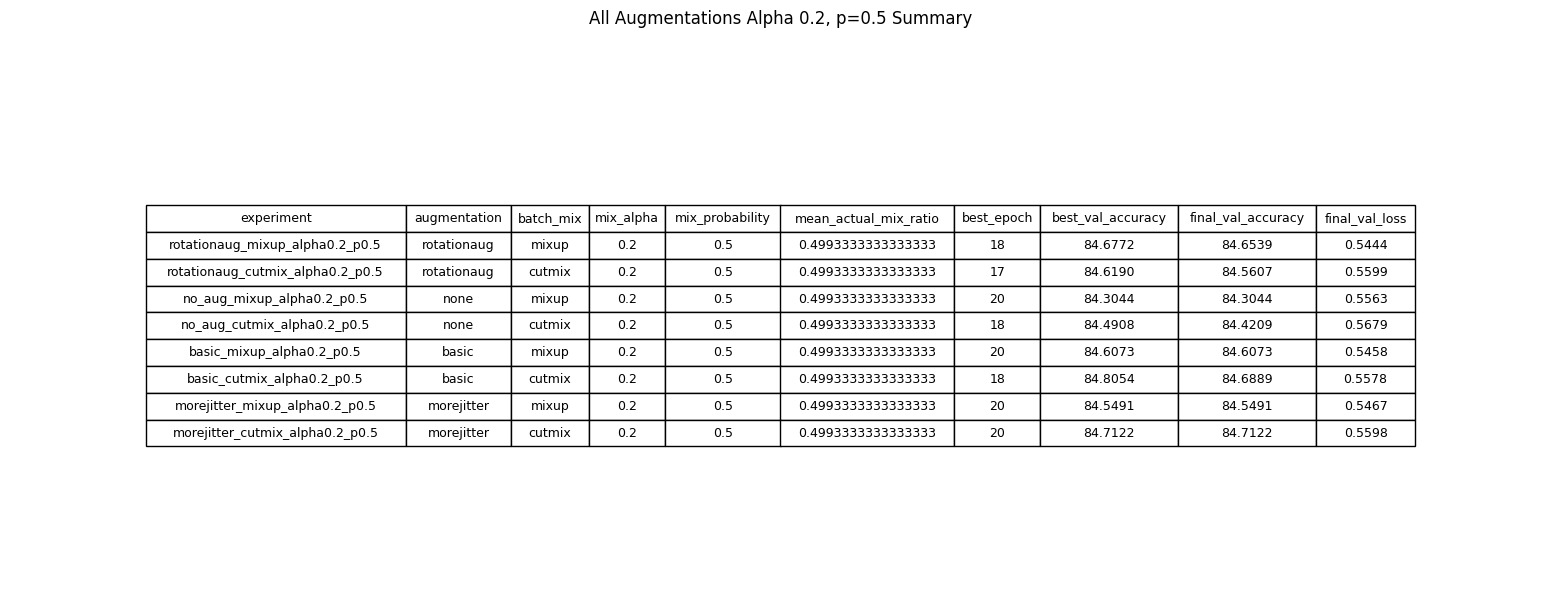

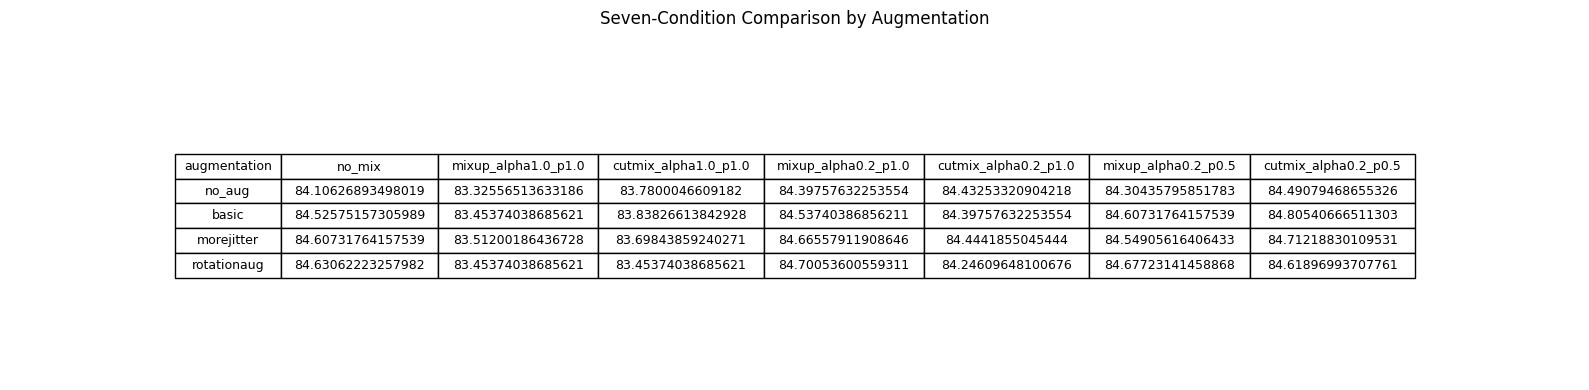

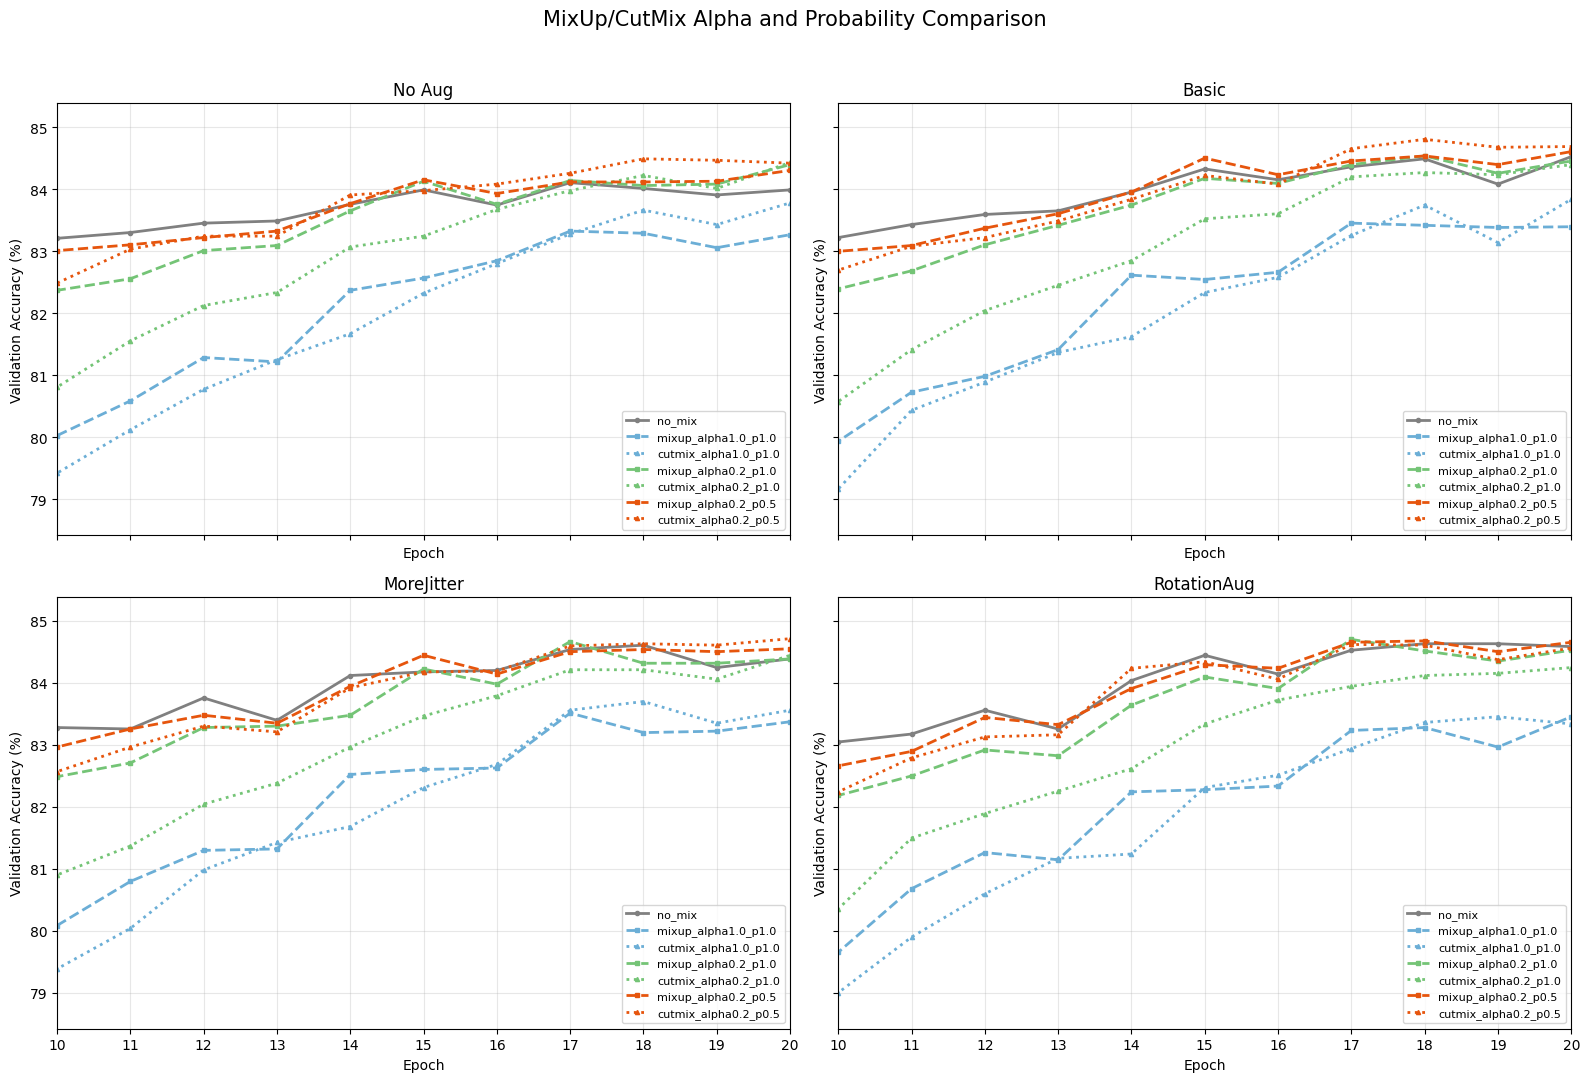

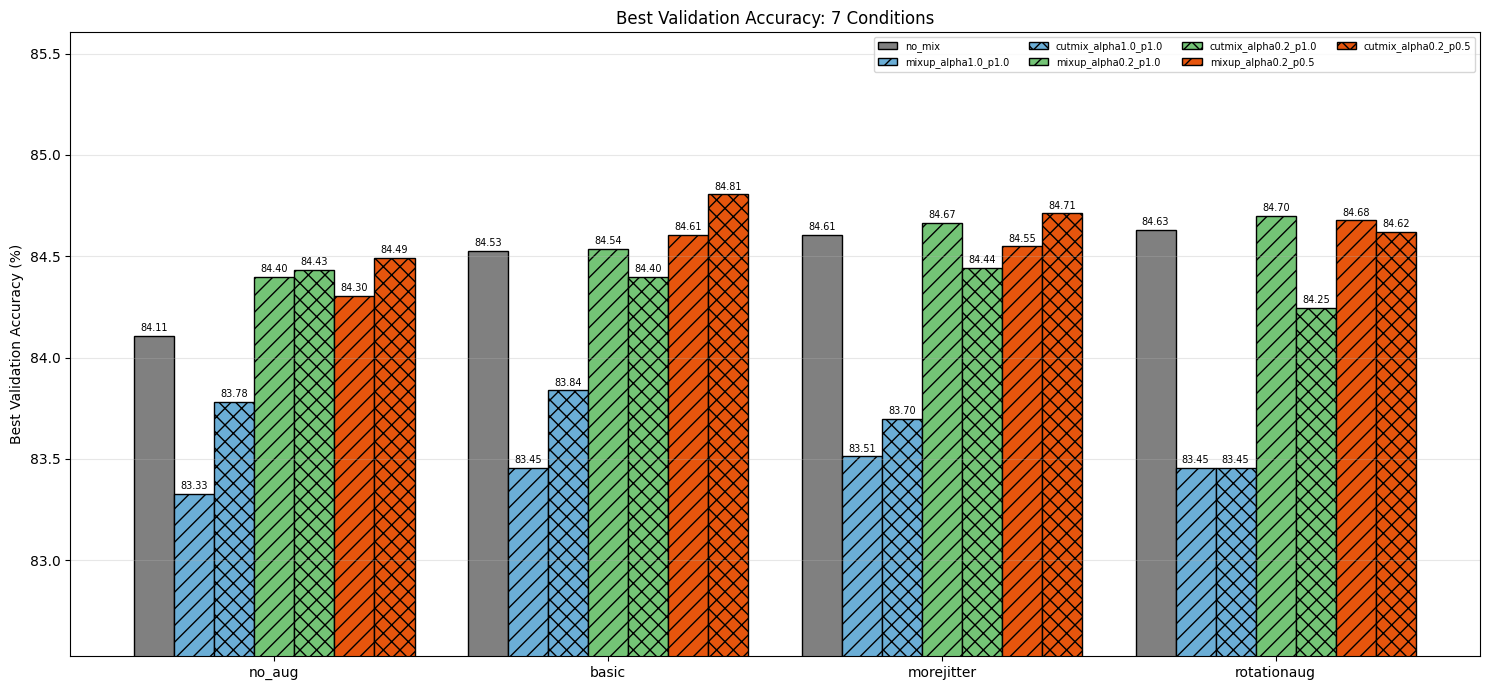

In [11]:

def save_dataframe_table(dataframe, filename, title):
    display_df = dataframe.copy()
    for column in [
        "best_val_accuracy",
        "final_val_accuracy",
        "final_val_loss",
    ]:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(
                lambda value: f"{value:.4f}"
            )

    figure_height = max(3.5, 0.55 * len(display_df) + 1.8)
    fig, ax = plt.subplots(figsize=(16, figure_height))
    ax.axis("off")
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_column_width(col=list(range(len(display_df.columns))))
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    ax.set_title(title, pad=20)
    fig.tight_layout()
    fig.savefig(
        RESULT_DIR / filename,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


CONDITION_STYLES = {
    "no_mix": {"color": "gray", "linestyle": "-", "marker": "o"},
    "mixup_alpha1.0_p1.0": {"color": "#6baed6", "linestyle": "--", "marker": "s"},
    "cutmix_alpha1.0_p1.0": {"color": "#6baed6", "linestyle": ":", "marker": "^"},
    "mixup_alpha0.2_p1.0": {"color": "#74c476", "linestyle": "--", "marker": "s"},
    "cutmix_alpha0.2_p1.0": {"color": "#74c476", "linestyle": ":", "marker": "^"},
    "mixup_alpha0.2_p0.5": {"color": "#e6550d", "linestyle": "--", "marker": "s"},
    "cutmix_alpha0.2_p0.5": {"color": "#e6550d", "linestyle": ":", "marker": "^"},
}


def save_alpha_comparison_plot(history_df, zoom_start_epoch=10):
    augmentation_order = ["none", "basic", "morejitter", "rotationaug"]
    titles = ["No Aug", "Basic", "MoreJitter", "RotationAug"]
    zoom_df = history_df[history_df["epoch"] >= zoom_start_epoch]
    zoom_min = zoom_df["val_accuracy"].min()
    zoom_max = zoom_df["val_accuracy"].max()
    zoom_padding = max(0.4, (zoom_max - zoom_min) * 0.1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=True)
    for ax, augmentation, title in zip(axes.flat, augmentation_order, titles):
        augmentation_df = history_df[
            history_df["augmentation"] == augmentation
        ]
        for experiment_name, group in augmentation_df.groupby(
            "experiment", sort=False
        ):
            first_row = group.iloc[0]
            condition = first_row["condition"]
            ax.plot(
                group["epoch"],
                group["val_accuracy"],
                label=condition,
                linewidth=2,
                markersize=3,
                **CONDITION_STYLES[condition],
            )
        ax.set_title(title)
        ax.set_xlim(zoom_start_epoch, EPOCHS)
        ax.set_ylim(zoom_min - zoom_padding, zoom_max + zoom_padding)
        ax.set_xticks(range(zoom_start_epoch, EPOCHS + 1))
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation Accuracy (%)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle("MixUp/CutMix Alpha and Probability Comparison", fontsize=15)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(
        RESULT_DIR / "alpha_comparison.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


def save_alpha_summary_plot(table_df):
    plot_df = table_df.copy()
    fig, ax = plt.subplots(figsize=(15, 7))
    x_positions = np.arange(len(plot_df.index))
    bar_width = 0.12

    for column_index, condition in enumerate(plot_df.columns):
        offsets = x_positions + (column_index - 3) * bar_width
        bars = ax.bar(
            offsets,
            plot_df[condition],
            width=bar_width,
            label=condition,
            color=CONDITION_STYLES[condition]["color"],
            edgecolor="black",
            hatch="//" if "mixup" in condition else "xx" if "cutmix" in condition else "",
        )
        labels = [
            f"{value:.2f}" if pd.notna(value) else ""
            for value in plot_df[condition]
        ]
        ax.bar_label(bars, labels=labels, padding=2, fontsize=7)

    value_min = np.nanmin(plot_df.to_numpy())
    value_max = np.nanmax(plot_df.to_numpy())
    ax.set_ylim(value_min - 0.8, value_max + 0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_df.index)
    ax.set_title("Best Validation Accuracy: 7 Conditions")
    ax.set_ylabel("Best Validation Accuracy (%)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7, ncol=4)
    fig.tight_layout()
    fig.savefig(
        RESULT_DIR / "alpha_comparison_summary.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


save_dataframe_table(
    alpha02_summary_df,
    "experiment_summary.png",
    "All Augmentations Alpha 0.2, p=0.5 Summary",
)
save_dataframe_table(
    comparison_table_df.rename_axis("augmentation").reset_index(),
    "alpha_comparison_summary_table.png",
    "Seven-Condition Comparison by Augmentation",
)
save_alpha_comparison_plot(comparison_df)
save_alpha_summary_plot(comparison_table_df)


## 11. 해석 기준과 삭제 방법

- `p=0.5`는 MixUp과 CutMix 중 하나를 선택하는 확률이 아니라, 해당 batch에 mixing을
  적용할 확률입니다.
- 평균 실제 적용 비율이 0.5 부근인지 `mean_actual_mix_ratio`로 확인합니다.
- p=0.5가 p=1.0보다 높다면 매 batch에 mixing을 적용한 것이 과도했을 가능성을 검토합니다.
- 차이가 매우 작다면 단일 seed 변동일 수 있으므로 확정적인 결론은 피합니다.
- Alpha 0.2가 같은 augmentation의 no-mix보다 낮다면 현재 조건에서는 batch mixing 자체가
  추가 이득을 주지 못했다고 해석할 수 있습니다.
- `no_aug + MixUp/CutMix`는 image transform augmentation만 없고 batch-level augmentation은
  적용된 조건입니다.

실험을 제거하려면 다음 두 항목만 삭제하면 됩니다.

- `node-2-alpha02-p05.ipynb`
- `results_resnet50_aug_alpha02_p05/`

기존 alpha=1.0 및 alpha=0.2 실험 파일은 읽기만 하며 변경하지 않습니다.
